### Hypothesis Testing (Z-Test: One- & Two-Sample, One- & Two-Sided)

##### Import libraries

In [72]:
import numpy as np
from scipy.stats import norm
from statsmodels.stats.weightstats import ztest

In [73]:
np.random.seed(0)

##### Population parameters (unknown in practice)

In [74]:
mu = 0.2
sigma = 1

##### Drawing 1 sample from the population N(0.2, 1)
###### We scale and shift the standard normal sample from np.random.randn() to match the desired population mean (mu) and standard deviation (sigma).

In [75]:
N = 100
x = np.random.randn(N)*sigma + mu
# x = np.random.normal(loc=mu, scale=sigma, size=N)
x

array([ 1.96405235,  0.60015721,  1.17873798,  2.4408932 ,  2.06755799,
       -0.77727788,  1.15008842,  0.04864279,  0.09678115,  0.6105985 ,
        0.34404357,  1.65427351,  0.96103773,  0.32167502,  0.64386323,
        0.53367433,  1.69407907, -0.00515826,  0.5130677 , -0.65409574,
       -2.35298982,  0.8536186 ,  1.0644362 , -0.54216502,  2.46975462,
       -1.25436567,  0.24575852,  0.01281615,  1.73277921,  1.66935877,
        0.35494743,  0.57816252, -0.68778575, -1.78079647, -0.14791215,
        0.35634897,  1.43029068,  1.40237985, -0.18732682, -0.10230275,
       -0.84855297, -1.22001794, -1.50627019,  2.1507754 , -0.30965218,
       -0.2380743 , -1.05279536,  0.97749036, -1.41389785, -0.01274028,
       -0.69546656,  0.5869025 , -0.31080514, -0.98063218,  0.17181777,
        0.62833187,  0.26651722,  0.5024719 , -0.43432209, -0.16274117,
       -0.47246045, -0.15955316, -0.61314628, -1.5262826 ,  0.37742614,
       -0.20178094, -1.43019835,  0.66278226, -0.70729836,  0.25

#### One - Sample Test


##### A) Two-sided test


##### Hypotheses for the two-sided Z-test

$$
H_0: \mu = 0 \quad \text{(population mean equals 0)}
$$

$$
H_1: \mu \neq 0 \quad \text{(population mean is different from 0)}
$$

In [76]:
# two-sided test - automated
ztest(x)
z_test, p_value = ztest(x)

alpha = 0.05

print(f"P-Value: {p_value:.4f} | Significance level (alpha): {alpha}")

if p_value < alpha:
    print("Reject H0 – the sample provides enough evidence that the population mean differs from 0.")
else:
    print("Fail to reject H0 – the sample does not provide sufficient evidence to conclude the population mean differs from 0.")

P-Value: 0.0103 | Significance level (alpha): 0.05
Reject H0 – the sample provides enough evidence that the population mean differs from 0.


##### Two-sided Z-test p-value using PDF and CDF of standard normal

##### For a two-sided Z-test, the p-value can be expressed either as areas under the PDF:

$$
p = \int_{|z_{\text{test}}|}^{\infty} f_Z(z)\, dz \; + \; \int_{-\infty}^{-|z_{\text{test}}|} f_Z(z)\, dz
$$

##### or equivalently using the CDF \(F_Z(z)\) of the standard normal distribution:

$$
p = 1 - F_Z(|z_{\text{test}}|) + F_Z(-|z_{\text{test}}|)
$$

##### where the standard normal PDF is:

$$
f_Z(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2 / 2} \quad \text{and} \quad F_Z(z) = P(Z \le z) = \int_{-\infty}^{z} f_Z(t)\, dt
$$
<div style="text-align: center;">
    <img src="https://www.six-sigma-material.com/images/xPvalueVisualAid.JPG.pagespeed.ic.Ge-eXtYLG8.webp" width="600">
</div>

In [77]:
# two-sided test - manual
mu_hat = x.mean()
sigma_hat = x.std(ddof=1)
z_test = mu_hat / (sigma_hat / np.sqrt(N))
p_right = 1 - norm.cdf(np.abs(z_test))
p_left = norm.cdf(-np.abs(z_test))
p_value = p_right + p_left

alpha = 0.05

print(f"P-Value: {p_value:.4f} | Significance level (alpha): {alpha}")

if p_value < alpha:
    print("Reject H0 – the sample provides enough evidence that the population mean differs from 0.")
else:
    print("Fail to reject H0 – the sample does not provide sufficient evidence to conclude the population mean differs from 0.")

P-Value: 0.0103 | Significance level (alpha): 0.05
Reject H0 – the sample provides enough evidence that the population mean differs from 0.


##### B) One-sided test - Larger

##### Hypotheses for the one-sided (right-tailed) Z-test

$$
H_0: \mu = 0 \quad \text{(population mean equals 0)}
$$

$$
H_1: \mu > 0 \quad \text{(population mean is greater than 0)}
$$

In [78]:
# one-sided test - automatic
z_test, p_value = ztest(x, alternative='larger')

alpha = 0.05

print(f"P-Value: {p_value:.4f} | Significance level (alpha): {alpha}")

if p_value < alpha:
    print("Reject H0 – the sample provides sufficient evidence that the population mean is greater than 0.")
else:
    print("Fail to reject H0 – the sample does not provide sufficient evidence to conclude that the population mean is greater than 0.")

P-Value: 0.0052 | Significance level (alpha): 0.05
Reject H0 – the sample provides sufficient evidence that the population mean is greater than 0.


##### One-sided (right-tailed) Z-test p-value using PDF and CDF of standard normal

For a one-sided (right-tailed) Z-test, the p-value can be expressed as the area under the PDF to the right of the observed Z-statistic:

$$
p = \int_{z_{\text{test}}}^{\infty} f_Z(z)\, dz
$$

or equivalently using the CDF \(F_Z(z)\) of the standard normal distribution:

$$
p = 1 - F_Z(z_{\text{test}})
$$

where the standard normal PDF is:

$$
f_Z(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2 / 2} \quad \text{and} \quad F_Z(z) = P(Z \le z) = \int_{-\infty}^{z} f_Z(t)\, dt
$$

<div style="text-align: center;">
    <img src="https://www.six-sigma-material.com/images/xPvalueVisualAid.JPG.pagespeed.ic.Ge-eXtYLG8.webp" width="600">
</div>

In [79]:
# one-sided test - manual
mu_hat = x.mean()
sigma_hat = x.std(ddof=1)
z_test = mu_hat / (sigma_hat / np.sqrt(N))
p_value = 1 - norm.cdf(z_test)

alpha = 0.05

print(f"P-Value: {p_value:.4f} | Significance level (alpha): {alpha}")

if p_value < alpha:
    print("Reject H0 – the sample provides sufficient evidence that the population mean is greater than 0.")
else:
    print("Fail to reject H0 – the sample does not provide sufficient evidence to conclude that the population mean is greater than 0.")

P-Value: 0.0052 | Significance level (alpha): 0.05
Reject H0 – the sample provides sufficient evidence that the population mean is greater than 0.


In [80]:
# null under a different reference value
mu0 = 0.2
ztest(x, value=mu0)

(np.float64(0.5904283402851699), np.float64(0.5549035151647227))

In [81]:
# null under a different reference value
mu_hat = x.mean()
sigma_hat = x.std(ddof=1)
z = (mu_hat - mu0) / (sigma_hat / np.sqrt(N))
p_right = 1 - norm.cdf(np.abs(z))
p_left = norm.cdf(-np.abs(z))
p = p_right + p_left
z, p

(np.float64(0.5904283402851698), np.float64(0.5549035151647228))

#### Two - Sample Test
##### Population parameters for two groups (unknown in practice)

##### Let the two groups have population means and standard deviations:

$$
\mu_0, \sigma_0 \quad \text{for group 0}
$$

$$
\mu_1, \sigma_1 \quad \text{for group 1}
$$

- ##### In practice, these population parameters are unknown.
- ##### We only observe samples \(X_0\) and \(X_1\) from each group and estimate the means and standard deviations from the data.

In [82]:
mu0 = 0.2
sigma0 = 1

N0 = 100
x0 = np.random.randn(N0)*sigma0 + mu0

mu1 = 0.5
sigma1 = 1

N1 = 100
x1 = np.random.randn(N1)*sigma1 + mu1

##### Hypotheses for two-sample (two-sided) Z-test

$$
H_0: \mu_0 = \mu_1 \quad \text{(population means of group 0 and group 1 are equal)}
$$

$$
H_1: \mu_0 \neq \mu_1 \quad \text{(population means of group 0 and group 1 are different)}
$$

In [83]:
z_test, p_value = ztest(x0, x1)

alpha = 0.05

print(f"P-Value: {p_value:.4f} | Significance level (alpha): {alpha}")

if p_value < alpha:
    print("Reject H0 – the sample provides sufficient evidence that the population means of group 0 and group 1 are different.")
else:
    print("Fail to reject H0 – the sample does not provide sufficient evidence to conclude that the population means of group 0 and group 1 are different.")

P-Value: 0.2612 | Significance level (alpha): 0.05
Fail to reject H0 – the sample does not provide sufficient evidence to conclude that the population means of group 0 and group 1 are different.


In [84]:
# two-sided test - manual
mu_hat0 = x0.mean()
mu_hat1 = x1.mean()
dmu_hat = mu_hat1 - mu_hat0
s2_hat0 = x0.var(ddof=1)
s2_hat1 = x1.var(ddof=1)
s_hat = np.sqrt(s2_hat0 / N0 + s2_hat1 / N1)
z = dmu_hat / s_hat # reference value is 0
p_right = 1 - norm.cdf(np.abs(z))
p_left = norm.cdf(-np.abs(z))
p_value = p_right + p_left

alpha = 0.05

print(f"P-Value: {p_value:.4f} | Significance level (alpha): {alpha}")

if p_value < alpha:
    print("Reject H0 – the sample provides sufficient evidence that the population means of group 0 and group 1 are different.")
else:
    print("Fail to reject H0 – the sample does not provide sufficient evidence to conclude that the population means of group 0 and group 1 are different.")

P-Value: 0.2612 | Significance level (alpha): 0.05
Fail to reject H0 – the sample does not provide sufficient evidence to conclude that the population means of group 0 and group 1 are different.


#### Show that we will reject the null hypothesis when the null hypothesis is true (false alarm) 5% of the time

In [85]:
num_tests = 10000
results = np.zeros(num_tests)
for i in range(num_tests):
  x1 = np.random.randn(100)
  x2 = np.random.randn(100)
  z, p = ztest(x1, x2)
  results[i] = (p < 0.05)
print(results.mean())

0.049


### Example - Titanic 2

In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.stats.weightstats import ztest

In [87]:
df = pd.read_csv('titanic_train.csv')

In [88]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [89]:
df[df['Survived'] == 1].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [90]:
x1 = df[df['Survived'] == 1]['Fare'].dropna().to_numpy()
x2 = df[df['Survived'] == 0]['Fare'].dropna().to_numpy()

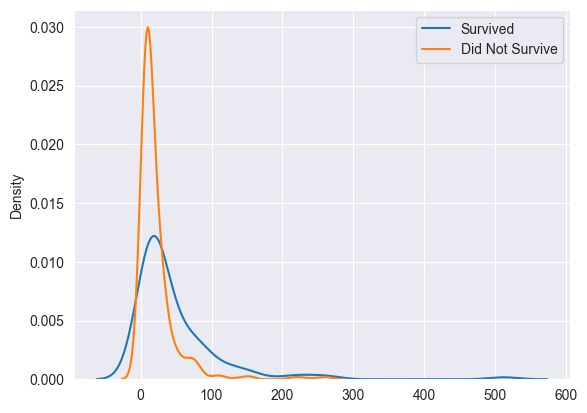

In [91]:
sns.kdeplot(x1, label='Survived')
sns.kdeplot(x2, label='Did Not Survive')
plt.legend();

In [92]:
x1.mean(), x2.mean()

(np.float64(48.39540760233918), np.float64(22.117886885245902))

##### Two-sample (two-sided) Z-test hypotheses

$$
H_0: \mu_0 = \mu_1 \quad \text{(population mean Fare for non-survivors equals that for survivors)}
$$

$$
H_1: \mu_0 \neq \mu_1 \quad \text{(population mean Fare for non-survivors is different from that for survivors)}
$$

In [93]:
ztest(x1, x2, usevar='unequal')

(np.float64(6.839099259085254), np.float64(7.969265634477824e-12))

In [94]:
# Two-sample Z-test implementation (automated)
import numpy as np
from scipy.stats import norm

# Sample sizes
N0 = len(x1)
N1 = len(x2)

# Sample means
mu_hat0 = x1.mean()
mu_hat1 = x2.mean()
dmu_hat = mu_hat1 - mu_hat0

# Sample variances
s2_hat0 = x1.var(ddof=1)
s2_hat1 = x2.var(ddof=1)

# Standard error of the difference
s_hat = np.sqrt(s2_hat0 / N0 + s2_hat1 / N1)

# Z-statistic (reference difference is 0)
z_test = dmu_hat / s_hat

# Two-sided p-value
p_value = 2 * (1 - norm.cdf(abs(z_test)))

# Significance level
alpha = 0.05

# Print results
print(f"Z-statistic: {z_test:.4f} | P-Value: {p_value:.4f} | Significance level (alpha): {alpha}")

# Decision
if p_value < alpha:
    print("Reject H0 – the sample provides sufficient evidence that the population means of group 0 and group 1 are different.")
else:
    print("Fail to reject H0 – the sample does not provide sufficient evidence to conclude that the population means of group 0 and group 1 are different.")

Z-statistic: -6.8391 | P-Value: 0.0000 | Significance level (alpha): 0.05
Reject H0 – the sample provides sufficient evidence that the population means of group 0 and group 1 are different.


#### Example - Bernoulli data

##### A/B Test for Advertisement Clicks

##### Objective
Determine if there is a significant difference in click-through rates (CTR) between two advertisements (A and B).


##### Data
The analysis is based on `advertisement_clicks.csv`, which contains:
* **advertisement_id**: The ad shown (A or B).
* **action**: Whether the user clicked (1) or not (0).


##### Hypotheses
* **Null hypothesis ($H_0$):** The click-through proportions for ads A and B are equal.
    $$H_0: p_A = p_B$$
* **Alternative hypothesis ($H_1$):** The click-through proportions are different.
    $$H_1: p_A \neq p_B$$


##### Theory / Method

1. **Extract actions** for each advertisement and calculate observed proportions ($\hat{p}_A, \hat{p}_B$).
2. **Pooled proportion under $H_0$**:
   Assuming $H_0$ is true, we combine the success rates to get a single estimate:
   $$\hat{p}_{pool} = \frac{\text{clicks}_A + \text{clicks}_B}{n_A + n_B}$$
3. **Standard error ($s$):**
   We use the pooled proportion to calculate the variance:
   $$s = \sqrt{\hat{p}_{pool}(1 - \hat{p}_{pool}) \left( \frac{1}{n_A} + \frac{1}{n_B} \right)}$$
4. **Compute Z-statistic:**
   $$z = \frac{\hat{p}_A - \hat{p}_B}{s}$$
5. **Compute two-sided p-value:**
   $$p = 2 \cdot (1 - \Phi(|z|))$$
   *Where $\Phi$ is the standard normal cumulative distribution function (CDF).*


##### Decision Rule
Compare the p-value to the significance level $\alpha = 0.05$:
* If **$p < 0.05$**: Reject $H_0$ $\rightarrow$ The ads have significantly different click-through rates.
* If **$p \ge 0.05$**: Fail to reject $H_0$ $\rightarrow$ No statistical evidence of a difference.

##### Interpretation
The Z-statistic and p-value indicate whether the observed difference is due to chance or a real performance gap. Using pooled variance aligns with the $H_0$ assumption that both groups share the same underlying probability.

In [95]:
df = pd.read_csv('advertisement_clicks.csv')

In [96]:
df.head()

,advertisement_id,action
0,B,1
1,B,1
2,A,0
3,B,0
4,A,1


In [97]:
import numpy as np
import pandas as pd
from scipy.stats import norm

df = pd.read_csv('advertisement_clicks.csv')

xA = df[df['advertisement_id']=='A']['action'].to_numpy()
xB = df[df['advertisement_id']=='B']['action'].to_numpy()

nA = len(xA)
nB = len(xB)

pA_hat = xA.mean()
pB_hat = xB.mean()

p_pool = (xA.sum() + xB.sum()) / (nA + nB)
s_hat = np.sqrt(p_pool * (1 - p_pool) * (1/nA + 1/nB))

z = (pA_hat - pB_hat) / s_hat
p = 2 * (1 - norm.cdf(abs(z)))

alpha = 0.05
if p < alpha:
    decision = "Reject H0 – proportions are significantly different"
else:
    decision = "Fail to reject H0 – no evidence of difference in proportions"

z, p, decision

(np.float64(-3.2144492244084213),
 np.float64(0.0013069502732125926),
 'Reject H0 – proportions are significantly different')